# BIPN 162 Final Project Code Notebook
*title of project*

*Alton Gu, Margaret Jones, Laura Liang*

## idk delete if theres nothing we care to write 

* hi

## Setup
*Are there packages that need to be imported, or datasets that need to be downloaded?*

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#import torch
#from torch import nn, optim

import tensorflow as tf
from keras.layers import Input, Dense, Lambda, LeakyReLU
from keras.models import Model
from keras.losses import MeanSquaredError #changed from mse
from keras.optimizers import Adam
from keras import backend as K

from scipy import linalg as LA
from sklearn.model_selection import train_test_split

#from sklearn import decomposition
#from sklearn.datasets import fetch_openml

In [6]:
#checking metabolite data (Gomari paper replication)
qmdiab = pd.read_csv("QMDiab_metabolite_data.csv")
aml = pd.read_csv("AML_metabolite_data.csv")
schiz = pd.read_csv("Schizophrenia_metabolite_data.csv")

print(qmdiab.shape)
print(aml.shape)
print(schiz.shape)

print(qmdiab.columns[:10])
print(aml.columns[:10])
print(schiz.columns[:10])


(358, 217)
(85, 217)
(201, 217)
Index(['M33228', 'M35186', 'M34214', 'M34419', 'M32635', 'M34395', 'M34389',
       'M33960', 'M35628', 'M33230'],
      dtype='object')
Index(['M33228', 'M35186', 'M34214', 'M34419', 'M32635', 'M34395', 'M34389',
       'M48258', 'M35628', 'M33230'],
      dtype='object')
Index(['M33228', 'M35186', 'M34214', 'M34419', 'M36600', 'M34395', 'M34389',
       'M48258', 'M35628', 'M33230'],
      dtype='object')


## Data Wrangling

### [placeholder but new data set]

In [7]:
df = pd.read_csv('GSE53697_RNAseq_AD.txt', delimiter='\t')
df.set_index('GeneSymbol', inplace=True)

# Isolates the RPKM, aka normalized data for analysis in a new dataframe.
rpkm_cols = [col for col in df.columns if '_rpkm' in col]
df_rpkm = df[rpkm_cols]


print(df_rpkm.head())
print(df_rpkm.shape) # There are 17 samples, and the expression levels of around 19,000 genes are measured.

              C1_rpkm    C2_rpkm    C3_rpkm    C4_rpkm     C5_rpkm  \
GeneSymbol                                                           
A1BG         0.847255   3.154229   1.486141   1.311722    1.306762   
A2M         59.425431  31.472732  86.078339  55.534038  138.315435   
NAT1         0.414799   0.162829   0.240973   0.398159    0.755531   
NAT2         0.037375   0.000000   0.052110   0.000000    0.051057   
SERPINA3    80.676061   2.432714   7.020434   8.278508   44.622384   

               C6_rpkm    C7_rpkm    C8_rpkm    A9_rpkm   A10_rpkm   A11_rpkm  \
GeneSymbol                                                                      
A1BG          1.058906   1.249770   1.116947   1.000632   0.849654   1.143676   
A2M         100.949251  47.482762  32.687338  61.751613  83.018173  50.567419   
NAT1          0.727852   0.287390   0.341521   0.285194   0.312610   0.559920   
NAT2          0.251836   0.044391   0.134279   0.115637   0.042251   0.302706   
SERPINA3    153.708964 

In [8]:
#Transpose the matrix so rows = genes and columns = samples
X = df_rpkm.T

print(X.shape) #the 17 samples x 19185 genes are now oriented correctly
X.head()

(17, 19185)


GeneSymbol,A1BG,A2M,NAT1,NAT2,SERPINA3,AADAC,AAMP,AANAT,AARS,ABAT,...,SPANXB2,CD24,hCG_20857,LOC100134869,LOC100134934,UPLP,JMJD7,PLA2G4B,KILLIN,LOC100169752
C1_rpkm,0.847255,59.425431,0.414799,0.037375,80.676061,0.00000,39.779306,0.636713,123.482695,47.199009,...,0.0,2.844987,7.688450,0.904356,6.377405,22.803211,4.506585,6.381534,0.448840,0.0
C2_rpkm,3.154229,31.472732,0.162829,0.000000,2.432714,0.00000,28.962942,1.153572,85.326615,24.690574,...,0.0,3.563109,2.755647,6.694352,5.500519,52.880105,39.986711,39.816333,0.379489,0.0
C3_rpkm,1.486141,86.078339,0.240973,0.052110,7.020434,0.08499,31.213799,0.819454,103.457218,61.532754,...,0.0,0.849995,7.457167,2.229099,5.510377,24.160293,14.137515,14.278326,0.449291,0.0
C4_rpkm,1.311722,55.534038,0.398159,0.000000,8.278508,0.00000,43.718319,0.188053,124.328377,61.506247,...,0.0,0.866940,6.032370,2.269403,7.518330,16.700800,9.934433,11.578654,0.433044,0.0
C5_rpkm,1.306762,138.315435,0.755531,0.051057,44.622384,0.00000,20.053570,0.802892,71.778959,58.554991,...,0.0,3.022816,2.739921,4.632831,5.399011,37.943829,11.463553,14.411560,0.408767,0.0


In [9]:
#Remove the genes with zero variance
X = X.loc[:, X.var() > 0]

#Log transform expression since RNA-seq expression is skewed
X = np.log1p(X)

#Select highly variable genes
gene_var = X.var(axis=0)
top_genes = gene_var.sort_values(ascending=False).head(2000).index
X = X[top_genes]

#Standardize features 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape)

(17, 2000)


### Wrangling of Reference Dataset (Gomari et al.)

In [10]:
df_schizo = pd.read_csv('Schizophrenia_metabolite_data.csv')
df_AML = pd.read_csv('AML_metabolite_data.csv')
df_QMD = pd.read_csv('QMDiab_metabolite_data.csv')

combined_df = pd.concat([df_schizo, df_AML, df_QMD], axis=0, join='inner')
combined_df = combined_df.drop_duplicates()
Y = combined_df.values #PCA only accepts numpy arrays

print(combined_df.head())
print(combined_df.shape)

     M33228    M35186    M34214    M34419    M34395    M34389    M35628  \
0 -0.224790  0.367972  0.213836  0.034424 -0.563072 -0.822089 -0.043932   
1 -1.365763 -0.250218 -1.102545  0.106423  0.547012  0.831003 -0.235921   
2  1.361526  1.419471  0.095614  1.458757 -0.131300  0.118827  1.122446   
3 -1.129735 -0.605956 -0.677170 -0.660245  1.392298  1.474983 -0.627671   
4 -0.402553 -0.924436  0.203205  0.649445 -0.653498 -0.428191 -0.667663   

     M33230    M21127    M33955  ...    M37202    M37203    M35527    M37190  \
0  0.765081 -1.229083  0.376804  ...  1.393283  0.668735 -1.156433  1.380834   
1  0.485585 -0.849375  0.587461  ...  0.799889  0.910195 -0.636947  1.442837   
2  0.505534 -0.656467  1.113982  ... -2.641975 -3.679084 -0.677344 -3.368232   
3  0.034415 -1.640713 -0.864807  ...  1.029772  0.551563 -1.768515  1.591040   
4 -0.650306 -0.145957 -0.191565  ...  0.729900  1.548937  1.241594  0.203979   

     M37198    M38178    M39379    M38768    M37506    M37097  
0  1

## Data Analysis & Results

### Analysis using PCA

#### PCA on reference dataset (Gomari et al.):

In [11]:
#PCA fn from Gomari et al. 

def PCA(data):
    
    data_raw = data
    #centering the data
    data -= np.mean(data, axis = 0)  

    cov = np.cov(data, rowvar = False)

    evals , evecs = LA.eigh(cov)

    # sort the eigenvalues (and eigenvectors accordingly) descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    
    # sort the eigenvectors
    S = evecs[:,idx]
    
    A = np.dot(data, S) 
    
    np.testing.assert_array_almost_equal(np.matmul(A, LA.inv(S)), data_raw)
    
    # calculate loadings of each PCA component
    loadings = S * np.sqrt(evals)
    
    return([A, S, loadings])

A, S, loadings = PCA(Y)

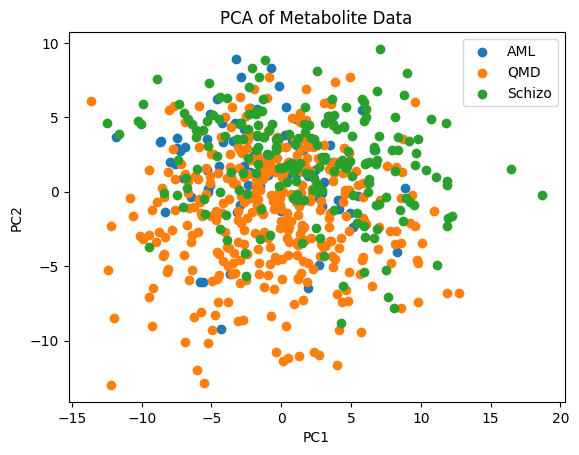

In [12]:
labels = (["Schizo"] * len(df_schizo) +
          ["AML"] * len(df_AML) +
          ["QMD"] * len(df_QMD))

labels = np.array(labels)

for group in np.unique(labels):
    subset = A[labels == group]
    plt.scatter(subset[:,0], subset[:,1], label=group)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Metabolite Data")
plt.legend()
plt.show()

#### PCA on **new** bulk RNAseq dataset:

### Analysis using VAE

### PCA and VAE Comparisons